<a href="https://colab.research.google.com/github/docling-project/docling/blob/main/docs/examples/visual_grounding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visual grounding

| Step | Tech | Execution | 
| --- | --- | --- |
| Embedding | Hugging Face / Sentence Transformers | 💻 Local |
| Vector store | Milvus | 💻 Local |
| Gen AI | Groq API | 🌐 Remote | 

This example showcases Docling's **visual grounding** capabilities, which can be combined
with any agentic AI / RAG framework.

In this instance, we illustrate these capabilities leveraging the
[LangChain Docling integration](../../integrations/langchain/), along with a Milvus
vector store, as well as sentence-transformers embeddings.

## Setup

- 👉 For best conversion speed, use GPU acceleration whenever available; e.g. if running on Colab, use GPU-enabled runtime.
- Notebook uses Groq's OpenAI-compatible API.
- Requirements can be installed as shown below (`--no-warn-conflicts` meant for Colab's pre-populated Python env; feel free to remove for stricter usage):

In [1]:
%pip install -q --progress-bar off --no-warn-conflicts langchain-docling langchain-core langchain-huggingface langchain_milvus langchain matplotlib python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [14]:
import os
from pathlib import Path
from tempfile import mkdtemp

from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_docling.loader import ExportType

load_dotenv()

# https://github.com/huggingface/transformers/issues/5486:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
BASE_URL = "https://api.groq.com/openai/v1"
SOURCES = ["https://arxiv.org/pdf/2408.09869"]  # Docling Technical Report
EMBED_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"
GEN_MODEL_ID = "qwen/qwen3.8-27b"
QUESTION = "Which are the main AI models in Docling?"
PROMPT = PromptTemplate.from_template(
    "Context information is below.\n---------------------\n{context}\n---------------------\nGiven the context information and not prior knowledge, answer the query.\nQuery: {input}\nAnswer:\n",
)
TOP_K = 3
MILVUS_URI = str(Path(mkdtemp()) / "docling.db")

## Document store setup



## Document loading

We first define our converter, in this case including options for keeping page images (for visual grounding).

In [15]:
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=PdfPipelineOptions(
                generate_page_images=True,
                images_scale=2.0,
            ),
        )
    }
)

We set up a simple doc store for keeping converted documents, as that is needed for visual grounding further below.

In [16]:
doc_store = {}
doc_store_root = Path(mkdtemp())
for source in SOURCES:
    dl_doc = converter.convert(source=source).document
    file_path = Path(doc_store_root / f"{dl_doc.origin.binary_hash}.json")
    dl_doc.save_as_json(file_path)
    doc_store[dl_doc.origin.binary_hash] = file_path

[INFO] 2026-10-05 13:07:31,882 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-10-05 13:07:31,901 [RapidOCR] download_file.py:60: File exists and is valid: /home/neebal/Desktop/docling/.venv/lib/python3.12/site-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-10-05 13:07:31,902 [RapidOCR] main.py:63: Using /home/neebal/Desktop/docling/.venv/lib/python3.12/site-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-10-05 13:07:32,155 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-10-05 13:07:32,160 [RapidOCR] download_file.py:60: File exists and is valid: /home/neebal/Desktop/docling/.venv/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-10-05 13:07:32,161 [RapidOCR] main.py:63: Using /home/neebal/Desktop/docling/.venv/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-10-05 13:07:32,229 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

RapidOCR returned empty result!


2026-10-05 13:08:17,638 MatchingPostProcessor WARNING  Orphan pdf_cell 122 recovered to row=3 by nearest-row fallback (col=0, y=490.5, dist=48.6)
2026-10-05 13:08:17,640 MatchingPostProcessor WARNING  Orphan pdf_cell 123 recovered to row=3 by nearest-row fallback (col=0, y=490.5, dist=48.6)
2026-10-05 13:08:59,828 MatchingPostProcessor WARNING  Orphan pdf_cell 200 recovered to col=4 by nearest-column fallback (row=0, x=908.3, dist=26.3)
2026-10-05 13:08:59,829 MatchingPostProcessor WARNING  Orphan pdf_cell 201 recovered to col=4 by nearest-column fallback (row=0, x=910.0, dist=28.0)
2026-10-05 13:08:59,829 MatchingPostProcessor WARNING  Orphan pdf_cell 215 recovered to col=4 by nearest-column fallback (row=2, x=908.0, dist=26.0)
2026-10-05 13:08:59,829 MatchingPostProcessor WARNING  Orphan pdf_cell 216 recovered to col=4 by nearest-column fallback (row=1, x=908.3, dist=26.3)
2026-10-05 13:08:59,830 MatchingPostProcessor WARNING  Orphan pdf_cell 223 recovered to col=4 by nearest-column 

Now we can instantiate our loader and load documents.

In [17]:
from langchain_docling import DoclingLoader

from docling.chunking import HybridChunker

loader = DoclingLoader(
    file_path=SOURCES,
    converter=converter,
    export_type=ExportType.DOC_CHUNKS,
    chunker=HybridChunker(tokenizer=EMBED_MODEL_ID),
)

docs = loader.load()

RapidOCR returned empty result!


2026-10-05 13:10:07,513 MatchingPostProcessor WARNING  Orphan pdf_cell 122 recovered to row=3 by nearest-row fallback (col=0, y=490.5, dist=48.6)
2026-10-05 13:10:07,520 MatchingPostProcessor WARNING  Orphan pdf_cell 123 recovered to row=3 by nearest-row fallback (col=0, y=490.5, dist=48.6)
2026-10-05 13:10:52,902 MatchingPostProcessor WARNING  Orphan pdf_cell 200 recovered to col=4 by nearest-column fallback (row=0, x=908.3, dist=26.3)
2026-10-05 13:10:52,902 MatchingPostProcessor WARNING  Orphan pdf_cell 201 recovered to col=4 by nearest-column fallback (row=0, x=910.0, dist=28.0)
2026-10-05 13:10:52,903 MatchingPostProcessor WARNING  Orphan pdf_cell 215 recovered to col=4 by nearest-column fallback (row=2, x=908.0, dist=26.0)
2026-10-05 13:10:52,904 MatchingPostProcessor WARNING  Orphan pdf_cell 216 recovered to col=4 by nearest-column fallback (row=1, x=908.3, dist=26.3)
2026-10-05 13:10:52,904 MatchingPostProcessor WARNING  Orphan pdf_cell 223 recovered to col=4 by nearest-column 

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (708 > 512). Running this sequence through the model will result in indexing errors


> 👉 **NOTE**: As you see above, using the `HybridChunker` can sometimes lead to a warning from the transformers library, however this is a "false alarm" — for details check [here](https://docling-project.github.io/docling/faq/#hybridchunker-triggers-warning-token-indices-sequence-length-is-longer-than-the-specified-maximum-sequence-length-for-this-model).

Inspecting some sample splits:

In [18]:
for d in docs[:3]:
    print(f"- {d.page_content=}")
print("...")

- d.page_content='Version 1.0\nChristoph Auer Maksym Lysak Ahmed Nassar Michele Dolfi Nikolaos Livathinos Panos Vagenas Cesar Berrospi Ramis Matteo Omenetti Fabian Lindlbauer Kasper Dinkla Lokesh Mishra Yusik Kim Shubham Gupta Rafael Teixeira de Lima Valery Weber Lucas Morin Ingmar Meijer Viktor Kuropiatnyk Peter W. J. Staar\nAI4K Group, IBM Research R¨ uschlikon, Switzerland'
- d.page_content='Abstract\nThis technical report introduces Docling , an easy to use, self-contained, MITlicensed open-source package for PDF document conversion. It is powered by state-of-the-art specialized AI models for layout analysis (DocLayNet) and table structure recognition (TableFormer), and runs efficiently on commodity hardware in a small resource budget. The code interface allows for easy extensibility and addition of new features and models.'
- d.page_content='1 Introduction\nConverting PDF documents back into a machine-processable format has been a major challenge for decades due to their huge vari

## Ingestion

In [19]:
import json
from pathlib import Path
from tempfile import mkdtemp

from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain_milvus import Milvus
from pymilvus import connections

embedding = HuggingFaceEmbeddings(model_name=EMBED_MODEL_ID)


milvus_uri = str(Path(mkdtemp()) / "docling.db")  # or set as needed
vectorstore = Milvus(
    embedding_function=embedding,
    collection_name="docling_demo",
    connection_args={"uri": milvus_uri},
    # Milvus Lite (milvus-lite 3.x) requires an explicit metric_type;
    # COSINE suits the normalized sentence-transformers embeddings.
    index_params={"index_type": "FLAT", "metric_type": "COSINE"},
    drop_old=True,
    auto_id=True,
)
# pymilvus 2.6's MilvusClient no longer registers an ORM-style connection, but
# langchain-milvus 0.3.x still builds an ORM Collection under this alias, so we
# register it explicitly to avoid ConnectionNotExistException.
connections.connect(alias=vectorstore.alias, uri=milvus_uri)
vectorstore.add_documents(docs)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/tmp/ipykernel_131671/3047202865.py:26: PyMilvusDeprecationWarning: `connections.connect` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  connections.connect(alias=vectorstore.alias, uri=milvus_uri)
/home/neebal/Desktop/docling/.venv/lib/python3.12/site-packages/langchain_milvus/vectorstores/milvus.py:580: PyMilvusDeprecationWarning: `Collection` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  self._col_cache = Collection(self.collection_name, using=self.alias)
/home/neebal/Desktop/docling/.venv/lib/python3.12/site-packages/langchain_milvus/vectorstores/milvus.py:1041: PyMilvusDeprecationWarning: `Collection.indexes` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  for x in self.col.indexes:
/home/neebal/Desktop/docling/.venv/lib/python3.12/site-packages/langchain_milvus/vectorstores/milvus.py:1043: PyMilvusDeprecationWarning: `Index.to_dict` is

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49]

## RAG

In [20]:
from langchain_openai import ChatOpenAI

retriever = vectorstore.as_retriever(search_kwargs={"k": TOP_K})
# Groq exposes an OpenAI-compatible API, so ChatOpenAI works by overriding base_url.
llm = ChatOpenAI(
    base_url=BASE_URL,
    api_key=GROQ_API_KEY,
    model=GEN_MODEL_ID,
    temperature=0,
)


def clip_text(text, threshold=100):
    return f"{text[:threshold]}..." if len(text) > threshold else text

I1005 13:14:55.135254  139601 chttp2_transport.cc:1402] ipv4:127.0.0.1:39689: Got goaway [11] err=UNAVAILABLE:GOAWAY received; Error code: 11; Debug Text: too_many_pings {http2_error:11}
E1005 13:14:55.136215  139601 chttp2_transport.cc:1434] ipv4:127.0.0.1:39689: Received a GOAWAY with error code ENHANCE_YOUR_CALM and debug data equal to "too_many_pings". Current keepalive time (before throttling): 10000ms


In [21]:
from docling.chunking import DocMeta
from docling.datamodel.document import DoclingDocument
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnablePassthrough


def _format_docs(docs):
    return "\n\n".join(d.page_content for d in docs)


# langchain 1.x removed the legacy create_retrieval_chain /
# create_stuff_documents_chain helpers (now only in the separate langchain-classic
# package). This LCEL chain is the modern equivalent and returns the same
# {"input", "context", "answer"} structure the visual grounding below relies on.
rag_chain = RunnablePassthrough.assign(
    context=lambda x: retriever.invoke(x["input"]),
).assign(
    answer=(
        RunnableLambda(
            lambda x: {"input": x["input"], "context": _format_docs(x["context"])}
        )
        | PROMPT
        | llm
        | StrOutputParser()
    )
)
resp_dict = rag_chain.invoke({"input": QUESTION})

clipped_answer = clip_text(resp_dict["answer"], threshold=200)
print(f"Question:\n{resp_dict['input']}\n\nAnswer:\n{clipped_answer}")

Question:
Which are the main AI models in Docling?

Answer:
Based on the provided context, the main AI models initially released in Docling are:

1.  **A layout analysis model**: Described as an accurate object-detector for page elements.
2.  **TableFormer**: ...


### Visual grounding

Source 1:
  text: "3.2 AI models\nAs part of Docling, we initially release two highly capable AI models to the open-source community, which have been developed and published recently by our team. The first model is a layout analysis model, an accurate object-detector for page elements [13]. The second model is TableFormer [12, 9], a state-of-the-art table structure re..."
  page: 3


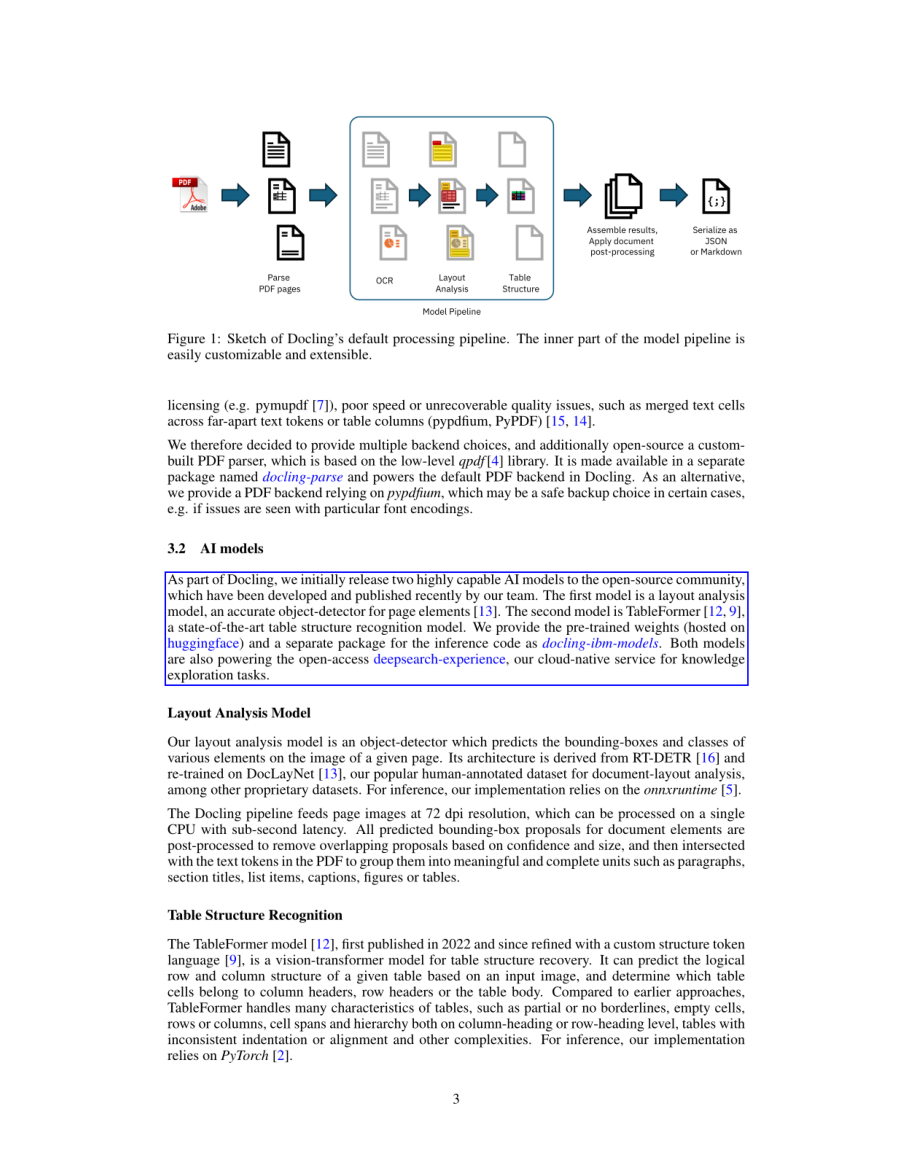

Source 2:
  text: "3 Processing pipeline\nDocling implements a linear pipeline of operations, which execute sequentially on each given document (see Fig. 1). Each document is first parsed by a PDF backend, which retrieves the programmatic text tokens, consisting of string content and its coordinates on the page, and also renders a bitmap image of each page to support ..."
  page: 2


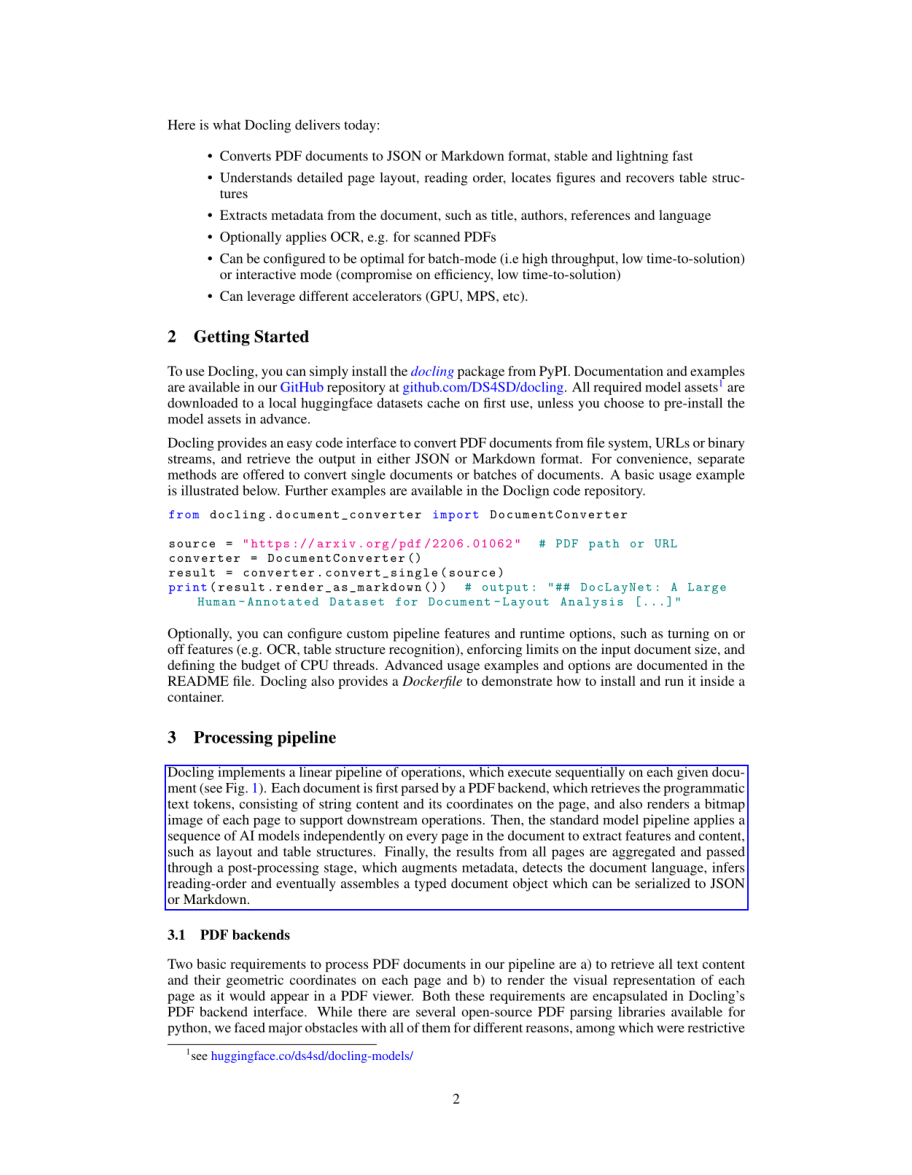

Source 3:
  text: "6 Future work and contributions\nDocling is designed to allow easy extension of the model library and pipelines. In the future, we plan to extend Docling with several more models, such as a figure-classifier model, an equationrecognition model, a code-recognition model and more. This will help improve the quality of conversion for specific types of ..."
  page: 5


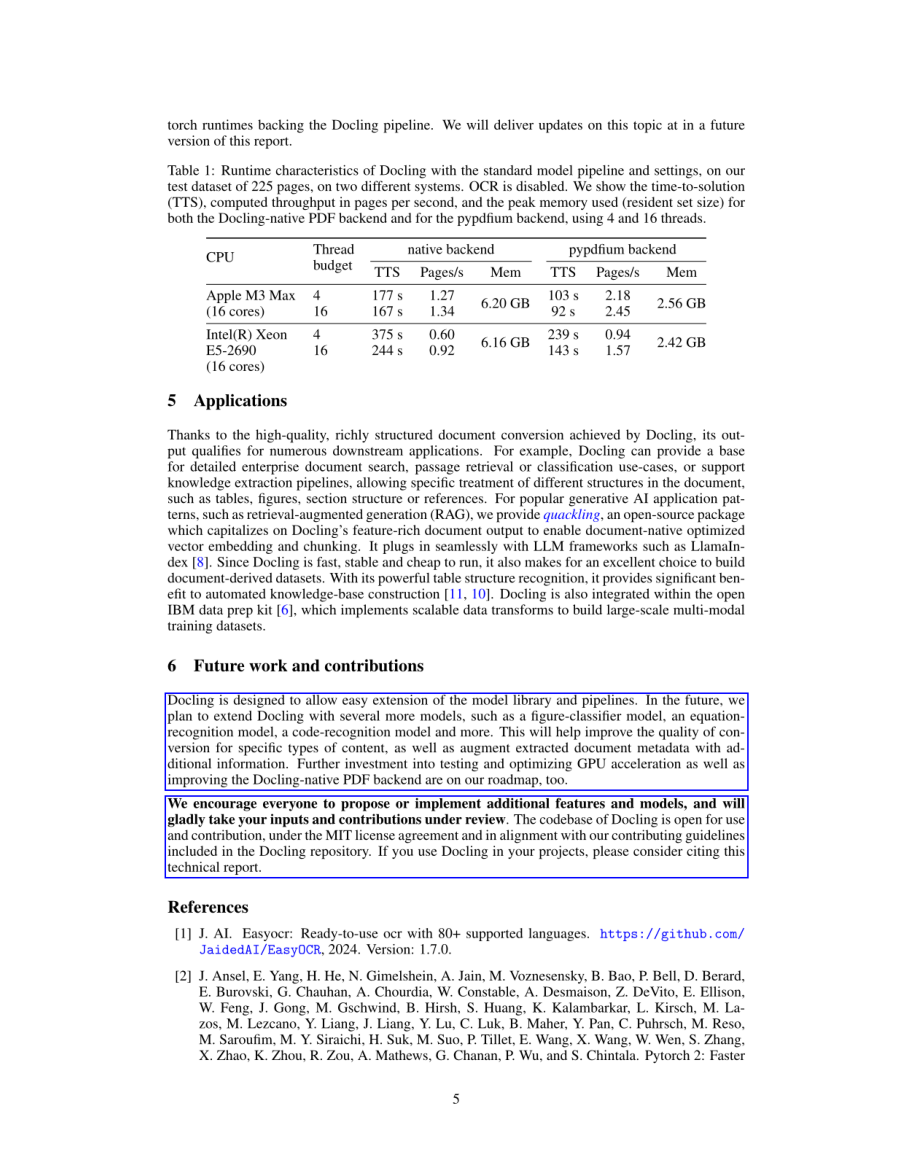

I1005 13:17:18.209162  139600 chttp2_transport.cc:1402] ipv4:127.0.0.1:39689: Got goaway [11] err=UNAVAILABLE:GOAWAY received; Error code: 11; Debug Text: too_many_pings {http2_error:11}
E1005 13:17:18.220367  139600 chttp2_transport.cc:1434] ipv4:127.0.0.1:39689: Received a GOAWAY with error code ENHANCE_YOUR_CALM and debug data equal to "too_many_pings". Current keepalive time (before throttling): 20000ms


In [22]:
import matplotlib.pyplot as plt
from PIL import ImageDraw

for i, doc in enumerate(resp_dict["context"][:]):
    image_by_page = {}
    print(f"Source {i + 1}:")
    print(f"  text: {json.dumps(clip_text(doc.page_content, threshold=350))}")
    meta = DocMeta.model_validate(doc.metadata["dl_meta"])

    # loading the full DoclingDocument from the document store:
    dl_doc = DoclingDocument.load_from_json(doc_store.get(meta.origin.binary_hash))

    for doc_item in meta.doc_items:
        if doc_item.prov:
            prov = doc_item.prov[0]  # here we only consider the first provenence item
            page_no = prov.page_no
            if img := image_by_page.get(page_no):
                pass
            else:
                page = dl_doc.pages[prov.page_no]
                print(f"  page: {prov.page_no}")
                img = page.image.pil_image
                image_by_page[page_no] = img
            bbox = prov.bbox.to_top_left_origin(page_height=page.size.height)
            bbox = bbox.normalized(page.size)
            thickness = 2
            padding = thickness + 2
            bbox.l = round(bbox.l * img.width - padding)
            bbox.r = round(bbox.r * img.width + padding)
            bbox.t = round(bbox.t * img.height - padding)
            bbox.b = round(bbox.b * img.height + padding)
            draw = ImageDraw.Draw(img)
            draw.rectangle(
                xy=bbox.as_tuple(),
                outline="blue",
                width=thickness,
            )
    for p in image_by_page:
        img = image_by_page[p]
        plt.figure(figsize=[15, 15])
        plt.imshow(img)
        plt.axis("off")
        plt.show()